# Discovering Spotify "sound archetypes" using audio features (Clustering + PCA)

**Group #:** 8

**Members:** Nicolas Beard Naranjo, Bobby Pakenham, Yi Long, Bushra Yousuf Bhatti, Sofia Mollon

**Dataset:** SpotifyAudioFeaturesApril2019 (Kaggle) - 130,663 tracks with 17 original features

**Research question:**  
Do Spotify tracks naturally cluster into meaningful "sound/mood archetypes" using only measurable audio features, and how do those clusters relate to popularity?

# 1) Load Data + Quick Look

In [ ]:
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_url = f"https://drive.google.com/uc?id=1Y3hRNJjVKu2lRlUiStemjp8v-oY6JV6V"

gdown.download(data_url, "SpotifyAudioFeaturesApril2019.csv", quiet=False)

df = pd.read_csv("SpotifyAudioFeaturesApril2019.csv")
print("Shape:", df.shape)
display(df.head(3))
print("\nColumns:", list(df.columns))

Downloading...
From: https://drive.google.com/uc?id=1Y3hRNJjVKu2lRlUiStemjp8v-oY6JV6V
To: /content/SpotifyAudioFeaturesApril2019.csv
100%|██████████| 20.4M/20.4M [00:00<00:00, 106MB/s] 


Shape: (130663, 17)


,artist_name,track_id,track_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,popularity
0,YG,2RM4jf1Xa9zPgMGRDiht8O,"Big Bank feat. 2 Chainz, Big Sean, Nicki Minaj",0.00582,0.743,238373,0.339,0.0,1,0.0812,-7.678,1,0.4090,203.927,4,0.118,15
1,YG,1tHDG53xJNGsItRA3vfVgs,BAND DRUM (feat. A$AP Rocky),0.02440,0.846,214800,0.557,0.0,8,0.2860,-7.259,1,0.4570,159.009,4,0.371,0
2,R3HAB,6Wosx2euFPMT14UXiWudMy,Radio Silence,0.02500,0.603,138913,0.723,0.0,9,0.0824,-5.890,0,0.0454,114.966,4,0.382,56



Columns: ['artist_name', 'track_id', 'track_name', 'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence', 'popularity']


In [ ]:
missing_rate = df.isna().mean().sort_values(ascending=False)
print("Top missing columns:")
display(missing_rate.head(10))

dup_rate = df.duplicated().mean()
print("Duplicate row fraction:", dup_rate)

Top missing columns:


,0
track_name,0.000008
artist_name,0.000000
track_id,0.000000
acousticness,0.000000
danceability,0.000000
duration_ms,0.000000
energy,0.000000
instrumentalness,0.000000
key,0.000000
liveness,0.000000


Duplicate row fraction: 0.0


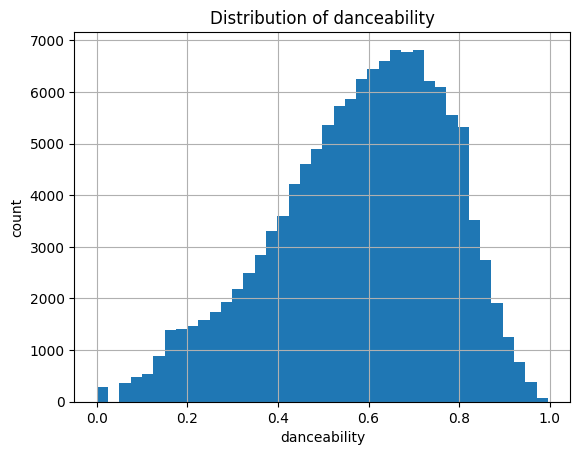

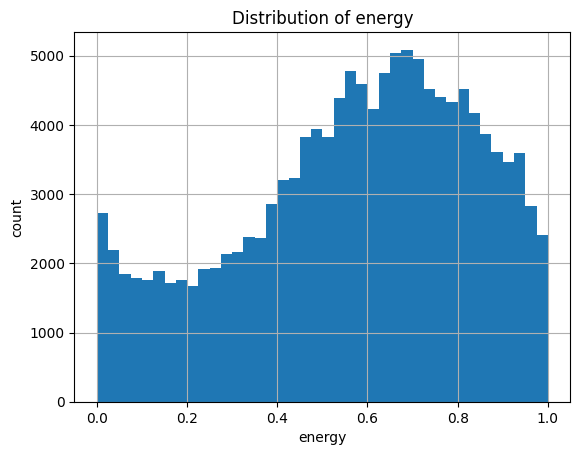

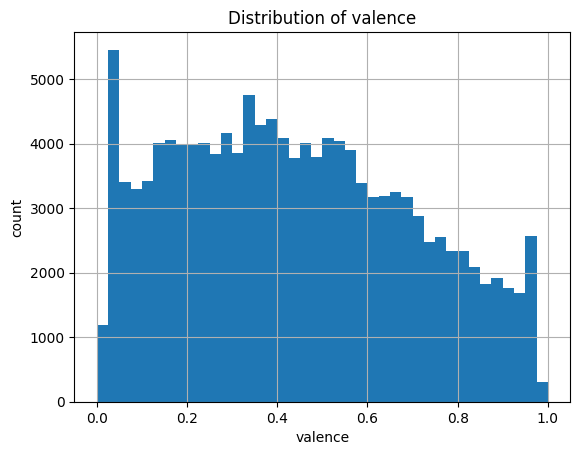

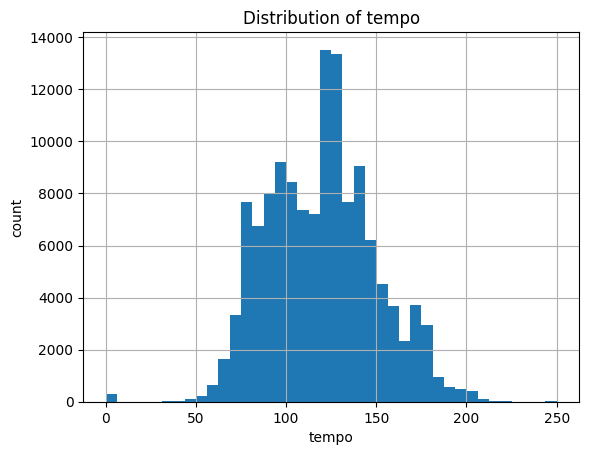

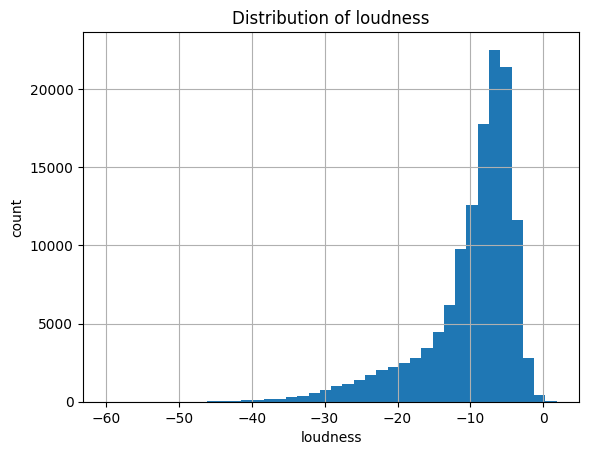

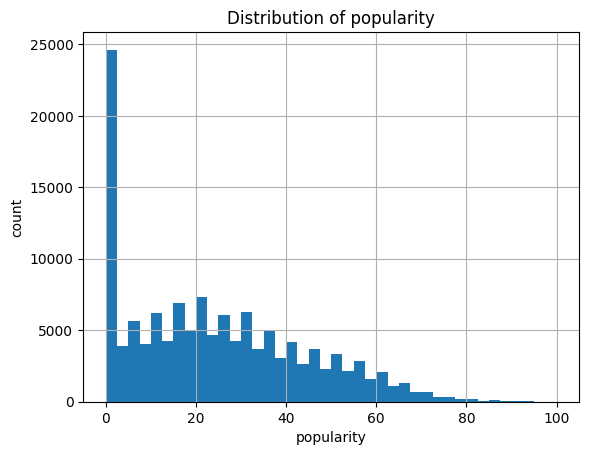

In [ ]:
for col in ["danceability", "energy", "valence", "tempo", "loudness", "popularity"]:
    plt.figure()
    df[col].hist(bins=40)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.show()

# 2) Preprocessing

We exclude columns that are identifiers or text labels:
- **artist_name, track_name, track_id**: do not represent measurable audio content and cause issues with numeric modeling.

We focus on numeric audio descriptors that represent sound:
- **danceability, energy, acousticness, instrumentalness, speechiness, valence, tempo, loudness, liveness**
- We keep **key, mode, time_signature, duration_ms** as they may capture musical structure.

Important: we **do not include popularity in clustering**.
- Popularity reflects external factors (marketing, artist fame, playlists), not purely audio properties.
- We use popularity later only to interpret clusters (e.g., which sound archetypes tend to be more popular).

Feature engineering:
- We create simple human-interpretable features:
  - **mood_index = energy * valence** (energetic + positive)
  - **acoustic_to_electric = acousticness - energy** (acoustic vs electric feel)
  - **log_duration = log(1 + duration_ms)** (reduces skew)

In [ ]:
# Drop non-numeric identifiers/text for modeling
df2 = df.copy()

# Create features
df2["mood_index"] = df2["energy"] * df2["valence"]
df2["acoustic_to_electric"] = df2["acousticness"] - df2["energy"]
df2["log_duration"] = np.log1p(df2["duration_ms"])

# Select features for clustering (exclude popularity on purpose)
feature_cols = [
    "acousticness","danceability","energy","instrumentalness","key",
    "liveness","loudness","mode","speechiness","tempo","time_signature",
    "valence","log_duration","mood_index","acoustic_to_electric"
]

# Drop rows missing any required features
before = df2.shape[0]
df2 = df2.dropna(subset=feature_cols + ["popularity"])
after = df2.shape[0]
print(f"Rows before: {before}, after dropping missing: {after} (removed {before-after})")

X = df2[feature_cols].copy()
y_pop = df2["popularity"].copy()  # for interpretation later

Rows before: 130663, after dropping missing: 130663 (removed 0)


# 3) Model choice: K-Means + PCA (with metric)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance (PC1, PC2):", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance (PC1, PC2): [0.30956306 0.10233283]
Total explained variance: 0.4118958895475901


## Model choice

We use **K-Means clustering** because:
- We expect multiple broad, compact "archetypes" of sound (e.g., acoustic/soft vs energetic/dance).
- K-Means is interpretable via cluster centroids (mean feature profiles).

We select the number of clusters using **silhouette score**, which measures:
- how tightly grouped each cluster is
- how separated clusters are from each other

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = {}
k_values = range(2, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = km.fit_predict(X_scaled)
    scores[k] = silhouette_score(X_scaled, labels)

best_k = max(scores, key=scores.get)
best_score = scores[best_k]

print("Silhouette scores:", scores)
print("Best k:", best_k, "with silhouette:", best_score)

In [ ]:
plt.figure()
plt.plot(list(scores.keys()), list(scores.values()), marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score vs k (K-Means)")
plt.show()

# 4) Fit final model + Results

In [ ]:
km = KMeans(n_clusters=best_k, random_state=0, n_init=10)
df2["cluster"] = km.fit_predict(X_scaled)

df2["cluster"].value_counts().sort_index()

In [ ]:
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df2["cluster"], s=6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters of Spotify tracks (PCA projection)")
plt.show()

print("Final silhouette score:", silhouette_score(X_scaled, df2["cluster"]))

The PCA visualization shows that most separation occurs along the first principal component, indicating that a small number of audio dimensions (primarily energy, loudness and acousticness) dominate the structure of Spotify music.

Based on feature profiles, the two clusters can be interpreted as:

- **Cluster 0 – Energetic / Electric music**
  - High energy, loudness, tempo and danceability
  - Low acousticness and instrumentalness
  - Typical of mainstream pop, hip-hop, EDM, rock

- **Cluster 1 – Acoustic / Instrumental music**
  - High acousticness and instrumentalness
  - Lower tempo, energy and loudness
  - Typical of acoustic, ambient, folk and background music

In [ ]:
profile = df2.groupby("cluster")[feature_cols].mean()
sizes = df2["cluster"].value_counts().sort_index()

display(profile)
print("\nCluster sizes:")
display(sizes)

In [ ]:
pop_stats = df2.groupby("cluster")["popularity"].agg(["mean","median","std","count"]).sort_values("mean", ascending=False)
display(pop_stats)

plt.figure()
pop_stats["mean"].plot(kind="bar")
plt.title("Average popularity by cluster")
plt.xlabel("cluster")
plt.ylabel("mean popularity")
plt.show()

In [ ]:
# Compare each cluster mean to overall mean to find distinctive features
overall = df2[feature_cols].mean()

for c in sorted(df2["cluster"].unique()):
    diff = (profile.loc[c] - overall).sort_values(ascending=False)
    print(f"\n=== Cluster {c} ===")
    print("Most ABOVE average:")
    print(diff.head(5))
    print("Most BELOW average:")
    print(diff.tail(5))

# 5) Predict popularity from audio only (Regression)

Question: can we predict **popularity** from audio features alone?

This is challenging because popularity depends on many external factors (artist fame, marketing, playlists).
So even a modest R² is informative: it indicates how much of popularity is explained by audio properties alone.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y_pop, test_size=0.2, random_state=0)

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=0,
    n_jobs=-1,
    max_depth=None
)
rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("R2:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))

plt.figure()
plt.scatter(y_test, pred, s=6)
plt.xlabel("True popularity")
plt.ylabel("Predicted popularity")
plt.title("Popularity prediction (Random Forest)")
plt.show()

The relatively low R² confirms that popularity depends strongly on external factors such as artist reputation, marketing and playlist placement, beyond audio characteristics alone.

In [ ]:
# 1. Map the test results back to the original track metadata
residual_results = pd.DataFrame({
    'track_name': df2.loc[y_test.index, 'track_name'],
    'artist_name': df2.loc[y_test.index, 'artist_name'],
    'actual_pop': y_test,
    'pred_pop': pred
})

# 2. Calculate the error (Residuals)
residual_results['residual'] = residual_results['actual_pop'] - residual_results['pred_pop']

# 3. Isolate the "Interesting" Data Points (Outliers in the top-left)
# These are the tracks that the model severely underestimated
top_outliers = residual_results[residual_results['residual'] > 30].sort_values(by='residual', ascending=False)

print(f"Top 10 tracks the model failed to predict (The 'Interesting' Data Points):")
display(top_outliers.head(10))

# 4. Critical Visual: Residual Plot
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.residplot(x=pred, y=y_test, lowess=True, line_kws={'color': 'red', 'lw': 2})
plt.title('Residual Analysis: Where the model fails to predict popularity')
plt.xlabel('Predicted Popularity')
plt.ylabel('Residual (Actual - Predicted)')
plt.show()

In [ ]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
display(importances.head(10))

plt.figure()
importances.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 feature importances (Random Forest)")
plt.xlabel("importance")
plt.show()

# Conclusions and ML Challenges

### Main findings
- **Acoustic DNA vs. Genre:** Our unsupervised K-Means model successfully identified two "Sound Archetypes" ($k=2$). This proves that the fundamental divide in modern music is not necessarily genre, but the technical split between **Energetic/Electric** and **Acoustic/Instrumental** profiles.
- **The Popularity Predictability Gap:** While Cluster 0 (Energetic) shows a higher average popularity, the Random Forest regression revealed that audio features alone are a poor predictor of "Superstardom."
- **The Success Ceiling:** Our model effectively predicts the popularity of "average" tracks, but it consistently underestimates the top 1% of hits. This suggests that while a "good sound" gets you into the system, external factors (marketing, artist brand, social media) are required to reach peak popularity.

### ML takeaways
- **Unsupervised learning** (K-Means) + **PCA visualization** reveals structure not captured by simple labels.
- **Silhouette score** helps choose k but interpretability still matters (k too large becomes hard to explain).

### Biggest challenges
- **Capturing Cultural Context (The "Outlier" Problem):** Our biggest challenge was dealing with tracks like **"Sunflower" (Post Malone)** and **"listen before i go" (Billie Eilish)**. Mathematically, these tracks have features similar to low-popularity acoustic songs, resulting in high residuals (errors). This highlights a limitation of using pure audio data without social metadata.
- Non-Linearity of Fame: We discovered a systematic bias in our regression (visualized in our **Residual Plot**). The model's tendency to "guess toward the mean" shows that popularity does not scale linearly with energy or danceability—there is a "viral" threshold that math cannot currently capture.
- **Feature Interaction:** Interpreting why certain clusters overlap in the PCA projection was challenging. It suggests that many tracks are "hybrids," and forcing them into distinct clusters oversimplifies the complexity of modern music production.

### Next steps
- Try **DBSCAN** to detect outliers (spoken-word tracks, extreme instrumentals).
- Try clustering **per decade/genre** (if metadata available) to see if archetypes shift across subgroups.

**AI Disclosure:** AI (Gemini and ChatGPT) were used to assist in the development and refinement of the model and plot code, as well as the search for the Spotify dataset we found.